In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
applications = pd.read_csv(
    "../data/applications_cleaned.csv",
    low_memory=False
)

In [3]:
applications['Approval_Status'].value_counts()

Approval_Status
Approved    70000
Rejected    12600
Name: count, dtype: int64

In [4]:
approval_rate = applications['Approval_Status'].value_counts(normalize=True) * 100
approval_rate

Approval_Status
Approved    84.745763
Rejected    15.254237
Name: proportion, dtype: float64

In [5]:
applications.columns.tolist()

['Application_ID',
 'Loan_ID',
 'Customer_ID',
 'Application_Date',
 'Approval_Date',
 'Loan_Purpose',
 'Source_Channel',
 'Processing_Fee',
 'Approval_Status',
 'Rejection_Reason']

In [6]:
rejection_reasons = applications[
    applications['Approval_Status'].str.lower() == 'rejected'
]['Rejection_Reason'].value_counts()

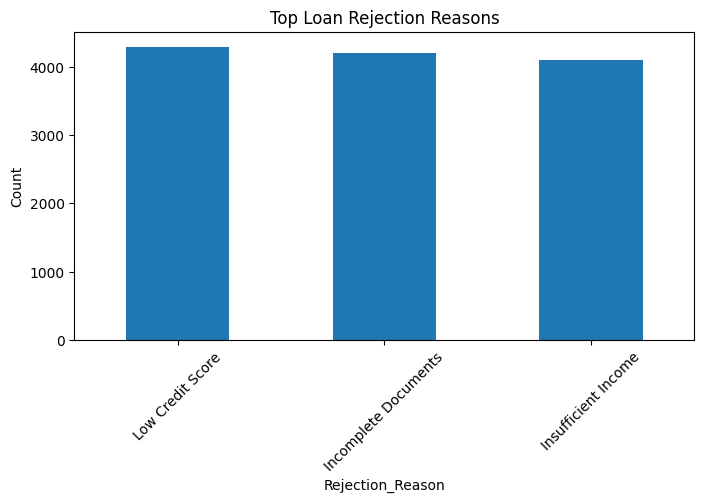

In [7]:
rejection_reasons.head(10).plot(kind='bar', figsize=(8,4))
plt.title("Top Loan Rejection Reasons")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [10]:
fee_comparison = applications.groupby(
    'Approval_Status'
)['Processing_Fee'].mean()

fee_comparison

Approval_Status
Approved    5252.395014
Rejected    5255.141587
Name: Processing_Fee, dtype: float64

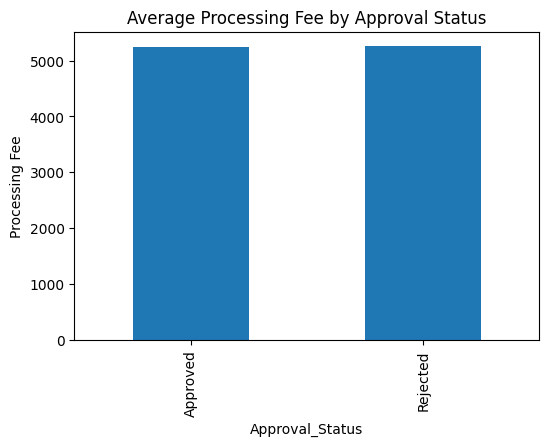

In [11]:
fee_comparison.plot(kind='bar', figsize=(6,4))
plt.title("Average Processing Fee by Approval Status")
plt.ylabel("Processing Fee")
plt.show()

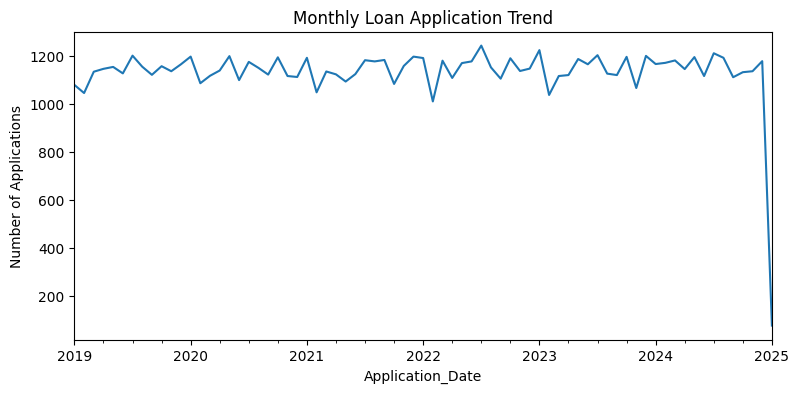

In [12]:
applications['Application_Date'] = pd.to_datetime(
    applications['Application_Date'],
    errors='coerce'
)

monthly_apps = applications.groupby(
    applications['Application_Date'].dt.to_period('M')
).size()

monthly_apps.plot(kind='line', figsize=(9,4))
plt.title("Monthly Loan Application Trend")
plt.ylabel("Number of Applications")
plt.show()

### Task 9 – Loan Application Insights

- Majority of loan applications are approved, indicating strong demand
- Credit-related factors dominate rejection reasons
- Rejected applications tend to have lower or zero processing fees
- Application volumes show time-based fluctuations
- Improving pre-screening can reduce rejection rates